Przykład 1: Wizualizacja overfitting vs underfitting
Model stopnia 1 (liniowy) nie jest w stanie uchwycić nieliniowej zależności (underfitting). Model
stopnia 15 dopasowuje się do każdego punktu, włącznie z szumem (overfitting). Model stopnia
4 najlepiej aproksymuje prawdziwą funkcję.

/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


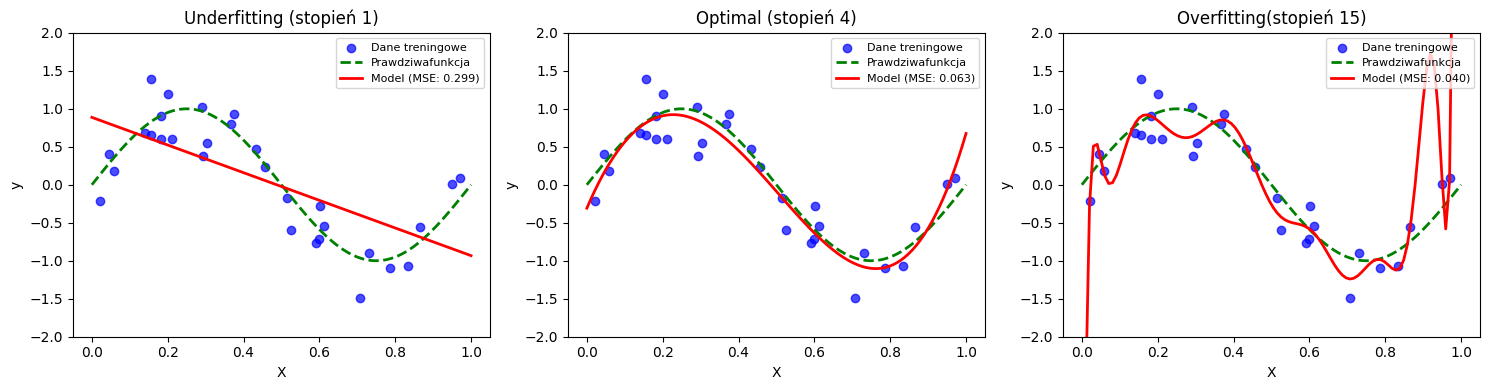

In [4]:
# Importujemy niezbędne biblioteki
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Ustawiamy seed dla reprodukowalności
np.random.seed(42)

# Generujemy dane z prawdziwą zależnością kwadratową + szum
n_samples = 30
X = np.sort(np.random.uniform(0, 1, n_samples))
y_true = np.sin(2 * np.pi * X) # Prawdziwa funkcja
y = y_true + np.random.normal(0, 0.3, n_samples) # Dane z szumem

# Przekształcamy X do odpowiedniego kształtu
X = X.reshape(-1, 1)

# Tworzymy modele o różnej złożoności
degrees = [1, 4, 15] # Stopień wielomianu: za prosty, optymalny, za złożony
titles = ['Underfitting (stopień 1)', 'Optimal (stopień 4)', 'Overfitting(stopień 15)']

# Przygotowujemy punkty do wykresu
X_plot = np.linspace(0, 1, 100).reshape(-1, 1)

# Tworzymy wykres
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, degree, title in zip(axes, degrees, titles):
    # Tworzymy pipeline: transformacja wielomianowa + regresja
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )

    # Trenujemy model
    model.fit(X, y)

    # Predykcja
    y_pred = model.predict(X)
    y_plot = model.predict(X_plot)

    # Obliczamy błąd treningowy
    train_mse = mean_squared_error(y, y_pred)

    # Rysujemy wykres
    ax.scatter(X, y, color='blue', alpha=0.7, label='Dane treningowe')
    ax.plot(X_plot, np.sin(2 * np.pi * X_plot), 'g--', label='Prawdziwafunkcja', linewidth=2)
    ax.plot(X_plot, y_plot, 'r-', label=f'Model (MSE: {train_mse:.3f})', linewidth=2)
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=8)
    ax.set_ylim(-2, 2)

plt.tight_layout()
plt.savefig('overfitting_comparison.png', dpi=100)
plt.show()

Przykład 2: Diagnostyka overfitting przez porównanie train/test error
Wykres pokazuje klasyczny wzorzec overfitting: błąd treningowy stale maleje ze wzrostem

/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


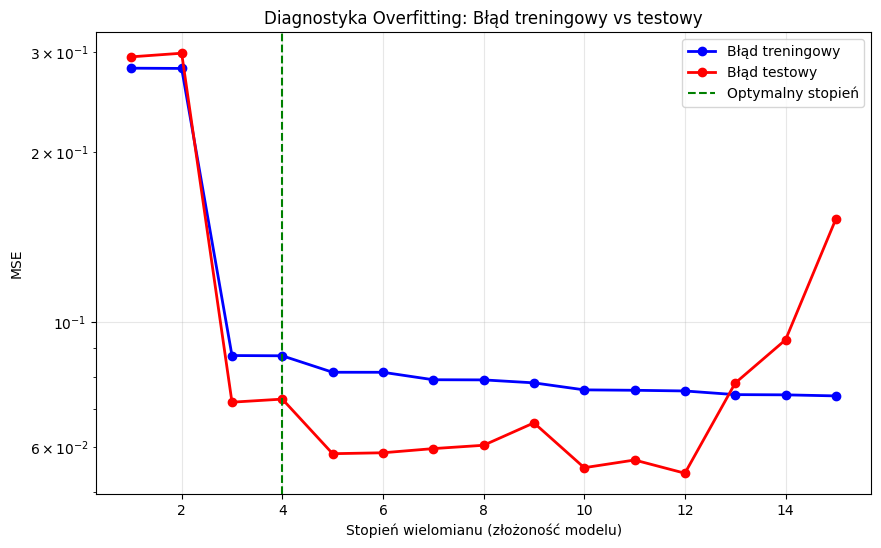

Optymalny stopień wielomianu: 12
Minimalny błąd testowy: 0.0540


In [2]:
# Importujemy biblioteki
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Generujemy dane
np.random.seed(42)
n_samples = 100
X = np.sort(np.random.uniform(0, 1, n_samples)).reshape(-1, 1)
y = np.sin(2 * np.pi * X.ravel()) + np.random.normal(0, 0.3, n_samples)

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=42
)

# Testujemy różne stopnie wielomianu
degrees = range(1, 16)
train_errors = []
test_errors = []

for degree in degrees:
    # Tworzymy i trenujemy model
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )
    model.fit(X_train, y_train)

    # Obliczamy błędy
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_errors.append(mean_squared_error(y_train, train_pred))
    test_errors.append(mean_squared_error(y_test, test_pred))

# Wykres błędów treningowych i testowych
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, 'b-o', label='Błąd treningowy', linewidth=2, markersize=6)
plt.plot(degrees, test_errors, 'r-o', label='Błąd testowy', linewidth=2, markersize=6)
plt.axvline(x=4, color='green', linestyle='--', label='Optymalny stopień')
plt.xlabel('Stopień wielomianu (złożoność modelu)')
plt.ylabel('MSE')
plt.title('Diagnostyka Overfitting: Błąd treningowy vs testowy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log') # Skala logarytmiczna dla lepszej czytelności
plt.savefig('train_test_error.png', dpi=100)
plt.show()

# Znajdujemy optymalny stopień
optimal_degree = degrees[np.argmin(test_errors)]
print(f"Optymalny stopień wielomianu: {optimal_degree}")
print(f"Minimalny błąd testowy: {min(test_errors):.4f}")

Przykład 3: Bias-Variance Trade-off na rzeczywistych danych 

Diagnoza modelu:
Jeśli train error ≈ test error i oba wysokie → underfitting → zwiększ złożoność modelu
Jeśli train error niski, test error wysoki → overfitting → zastosuj regularyzację
Jeśli oba niskie i podobne → model dobrze generalizuje

Warning
Częsty błąd: Używanie tylko błędu treningowego do oceny modelu. Zawsze porównuj z
błędem na zbiorze testowym lub walidacyjnym!

Porównanie modeli o różnej złożoności:
                Model  Train MSE  Test MSE  Liczba cech
    Linear Regression   0.553029  0.511932            8
Polynomial (degree=2)   0.408155  0.506149           44
    Ridge (alpha=1.0)   0.553043  0.511999            8


/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martus

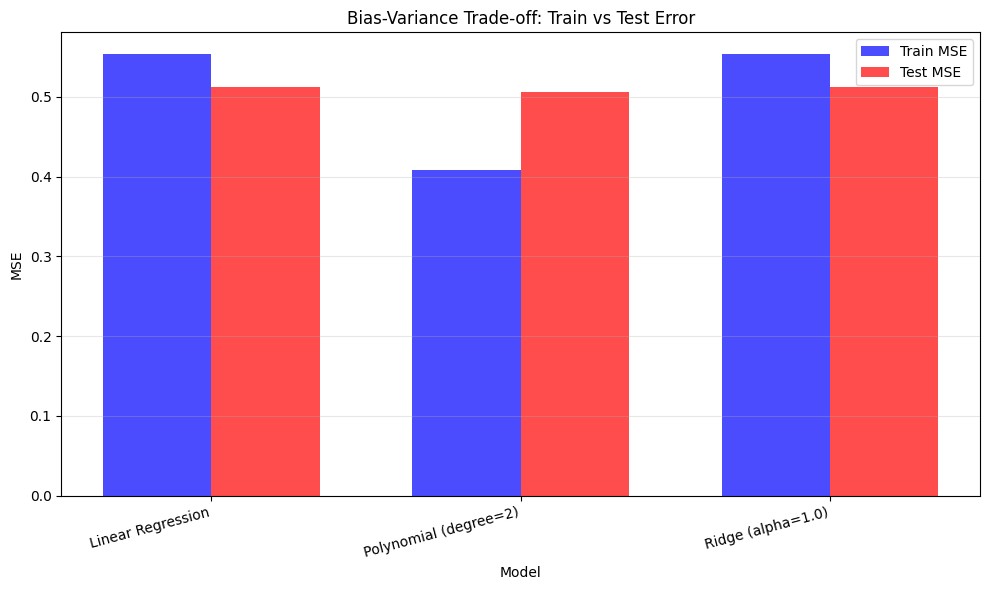

In [6]:
# Importujemy biblioteki
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Wczytujemy dane California Housing
california = fetch_california_housing()
X = california.data
y = california.target

# Dla szybkości używamy próbki danych
np.random.seed(42)
sample_idx = np.random.choice(len(X), size=2000, replace=False)
X_sample = X[sample_idx]
y_sample = y[sample_idx]

# Podział danych
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.3, random_state=42
)

# Standaryzacja
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Porównanie modeli o różnej złożoności
results = []

# Model 1: Regresja liniowa (baseline)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
train_pred = lr.predict(X_train_scaled)
test_pred = lr.predict(X_test_scaled)
results.append({
    'Model': 'Linear Regression',
    'Train MSE': mean_squared_error(y_train, train_pred),
    'Test MSE': mean_squared_error(y_test, test_pred),
    'Liczba cech': X_train_scaled.shape[1]
})

# Model 2: Regresja z cechami wielomianowymi stopnia 2
poly2 = make_pipeline(
PolynomialFeatures(degree=2, include_bias=False),
LinearRegression()
)
poly2.fit(X_train_scaled, y_train)
train_pred = poly2.predict(X_train_scaled)
test_pred = poly2.predict(X_test_scaled)
n_features_poly2 = poly2.named_steps['polynomialfeatures'].n_output_features_
results.append({
    'Model': 'Polynomial (degree=2)',
    'Train MSE': mean_squared_error(y_train, train_pred),
    'Test MSE': mean_squared_error(y_test, test_pred),
    'Liczba cech': n_features_poly2
})

# Model 3: Regresja z Ridge (L2 regularyzacja)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
train_pred = ridge.predict(X_train_scaled)
test_pred = ridge.predict(X_test_scaled)
results.append({
    'Model': 'Ridge (alpha=1.0)',
    'Train MSE': mean_squared_error(y_train, train_pred),
    'Test MSE': mean_squared_error(y_test, test_pred),
    'Liczba cech': X_train_scaled.shape[1]
})

# Wyświetlamy wyniki
results_df = pd.DataFrame(results)
print("Porównanie modeli o różnej złożoności:")
print(results_df.to_string(index=False))

# Wizualizacja
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(results_df))
width = 0.35
bars1 = ax.bar(x_pos - width/2, results_df['Train MSE'], width, label='Train MSE', color='blue', alpha=0.7)
bars2 = ax.bar(x_pos + width/2, results_df['Test MSE'], width, label='Test MSE', color='red', alpha=0.7)
ax.set_xlabel('Model')
ax.set_ylabel('MSE')
ax.set_title('Bias-Variance Trade-off: Train vs Test Error')
ax.set_xticks(x_pos)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('bias_variance_tradeoff.png', dpi=100)
plt.show()


2. Regularyzacja L2 (Ridge Regression)

Regularyzacja L2 (Ridge) dodaje do funkcji kosztu karę proporcjonalną do sumy
kwadratów współczynników: Loss = MSE + α ∑n
i=1 w2
i . Parametr α kontroluje siłę
regularyzacji - większa wartość oznacza silniejsze zmniejszanie współczynników.

Wprowadzenie
Ridge Regression zapobiega overfitting poprzez "kurczenie" (shrinkage) współczynników w
kierunku zera. W przeciwieństwie do L1, Ridge nigdy nie zeruje współczynników całkowicie -
zmniejsza je proporcjonalnie.

1. Funkcja kosztu Ridge

2a. MSE 
Σ(y - ŷ)²
Ograniczenie wielkości wag


2b. Kara L2
 α × Σw²
Minimalizacja błędu 

3. Model Ridge
